# Week 19: Tokenization and noise-aware sensor design

How do representation loss, token count and observation conditioning constrain the model before training?

**Prerequisites:** Weeks 5 and 7.3: QR sensing, POD and patch masks. Extend those ideas with matched diagnostics.

Allow 120 minutes plus the written analysis. Student edition: worked examples run immediately; set RUN_EXERCISES=True after completing the four functions. Incomplete tasks are reported, never counted as passes.

In [1]:
from pathlib import Path
import sys, tempfile, json
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'flowmllab/transformer_course.py').exists()),None)
if ROOT is None:
    raise RuntimeError('Extract the supplied course bundle and start Jupyter in its root; see docs/TRANSFORMER_COURSE.md for Colab upload setup.')
sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from flowmllab import transformer_course as lab
lab.seed_all(17)
cases,input_manifest=lab.load_data(ROOT)
EVIDENCE=ROOT/'results/transformer_course_v3'
# Any optional experiment must write into this disposable workspace.
workspace=tempfile.TemporaryDirectory(prefix='flowmllab-student-')
RUN_OUTPUT=Path(workspace.name)
task_status={}
print('Loaded checksummed simulated wake fields. No retained files will be rewritten.')


Loaded checksummed simulated wake fields. No retained files will be rewritten.


In [2]:
RUN_EXERCISES=False

## Compare three tokenizations of one simulated field

Flattening, patching and POD are different information contracts. Patching itself can be exactly invertible; truncating POD generally cannot. Attention storage scales with the square of token count, not the number of raw physical scalars alone.

Tokens / pairwise scores: {'point': (2496, 6230016), 'patch': (104, 10816), 'POD-vector': (1, 1)}
POD-vector means one entire coefficient vector per TIME token; it is not eight spatial tokens.


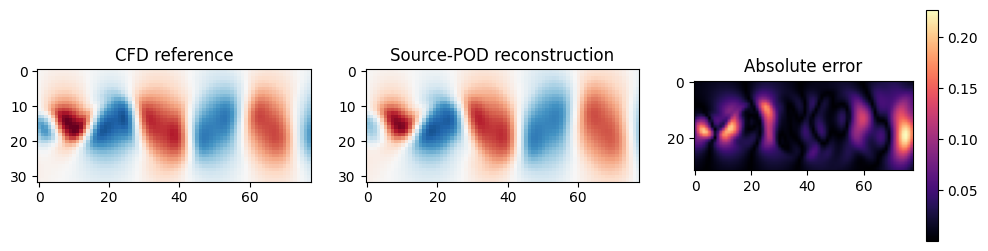

In [3]:
field=cases[110]['v'][100];h,w=field.shape
# 4 by 6 patches exactly tile the 32 by 78 ROI.
patches=field.reshape(h//4,4,w//6,6).transpose(0,2,1,3).reshape(-1,24)
restored=patches.reshape(h//4,w//6,4,6).transpose(0,2,1,3).reshape(h,w)
np.testing.assert_array_equal(restored,field)
representation=lab.Representation.fit(cases[90]['v'][:160],8)
reduced=representation.decode(representation.encode(field[None])).reshape(h,w)
counts={'point':h*w,'patch':len(patches),'POD-vector':1}
print('Tokens / pairwise scores:',{k:(n,n*n) for k,n in counts.items()})
print('POD-vector means one entire coefficient vector per TIME token; it is not eight spatial tokens.')
fig,axes=plt.subplots(1,3,figsize=(12,3))
bound=abs(field).max();axes[0].imshow(field,cmap='RdBu_r',vmin=-bound,vmax=bound);axes[0].set_title('CFD reference')
axes[1].imshow(reduced,cmap='RdBu_r',vmin=-bound,vmax=bound);axes[1].set_title('Source-POD reconstruction')
im=axes[2].imshow(abs(reduced-field),cmap='magma');axes[2].set_title('Absolute error');fig.colorbar(im,ax=axes[2]);plt.show()

## QR/D-optimal sensors under matched noise

Fit the sensing basis on source training data, then freeze locations. Compare 16 selected sensors against a 16-sensor geometry lattice under the same noise realization. This diagnostic builds directly on Week 5.

In [4]:
qr_ids=lab.qr_sensors(representation,16)
gy,gx=np.meshgrid(np.linspace(2,29,4,dtype=int),np.linspace(2,75,4,dtype=int),indexing='ij')
grid_ids=np.ravel_multi_index((gy.ravel(),gx.ravel()),field.shape)
rng=np.random.default_rng(1903);noise=rng.normal(size=16)*.01*cases[90]['v'][:160].std()
for name,sensors in [('QR/D-opt',qr_ids),('lattice',grid_ids)]:
    observed=field.ravel()[sensors]+noise
    coefficient=np.linalg.lstsq(representation.modes[sensors],observed-representation.mean[sensors],rcond=None)[0]
    reconstruction=coefficient@representation.modes.T+representation.mean
    print(name,'condition',np.linalg.cond(representation.modes[sensors]),'relative error',np.linalg.norm(reconstruction-field.ravel())/np.linalg.norm(field))

QR/D-opt condition 2.2572498539563086 relative error 0.26388372900733187
lattice condition 13.439052685011573 relative error 0.8725191791973435


## Task 1: Invert patching

Implement the inverse of the demonstrated 4x6 patch layout.

In [5]:
def unpatch(tokens,shape):
    raise NotImplementedError

In [6]:
if RUN_EXERCISES:
    np.testing.assert_array_equal(unpatch(patches,field.shape),field)
    task_status[1]=True
else:
    task_status[1]=False
print("Task 1:","PASS" if task_status[1] else "NOT SUBMITTED")

Task 1: NOT SUBMITTED


## Task 2: Representation floor

Compute the relative error of projecting a field into the frozen basis. Do not fit a new basis on the evaluation field.

In [7]:
def representation_floor(rep,field):
    raise NotImplementedError

In [8]:
if RUN_EXERCISES:
    assert 0<=representation_floor(representation,field)<1
    task_status[2]=True
else:
    task_status[2]=False
print("Task 2:","PASS" if task_status[2] else "NOT SUBMITTED")

Task 2: NOT SUBMITTED


## Task 3: Gappy solve

Recover modal coefficients from a supplied subset of observations using least squares, not matrix inversion.

In [9]:
def gappy(rep,ids,values):
    raise NotImplementedError

In [10]:
if RUN_EXERCISES:
    a=np.arange(8)*.1;synthetic=representation.mean+representation.modes@a
    np.testing.assert_allclose(gappy(representation,qr_ids,synthetic[qr_ids]),synthetic,atol=1e-8)
    task_status[3]=True
else:
    task_status[3]=False
print("Task 3:","PASS" if task_status[3] else "NOT SUBMITTED")

Task 3: NOT SUBMITTED


## Task 4: Memory accounting

Return float32 attention-score memory for B batches, H heads and N tokens; show the point/patch ratio.

In [11]:
def attention_bytes(batch,heads,tokens):
    raise NotImplementedError

In [12]:
if RUN_EXERCISES:
    assert attention_bytes(1,4,2496)/attention_bytes(1,4,104)==576
    task_status[4]=True
else:
    task_status[4]=False
print("Task 4:","PASS" if task_status[4] else "NOT SUBMITTED")

Task 4: NOT SUBMITTED


## Interpretation and submission

Submit the four completed functions, the requested plots/tables, and a 300-word claim ledger. Distinguish observations, fitted quantities, independent evaluation and unsupported extrapolation. Retain failed seeds. Use the lecture source for the rubric and assumptions.

In [13]:
print("Coding tasks passed:",sum(task_status.values()),"/",len(task_status))
workspace.cleanup()

Coding tasks passed: 0 / 4
